In [ ]:
import numpy as np

"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
# (5 points)
# TODO: Create the matrix described above

matrix = np.ones((5, 5))
matrix[1:-1, 1:-1] = 0

# Hint: Use np.ones and array slicing

# Task 2: Normalize a random array
# (5 points)
np.random.seed(42)
random_data = np.random.randn(100, 3)
# TODO: Normalize each column to have mean=0 and std=1

normalized= (random_data - np.mean(random_data, axis=0)) / np.std(
    random_data, axis=0
)


# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# TODO: Calculate theta_hat using the normal equation

theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y  


# TODO: Print the estimated coefficients and compare with true_theta

print("Estimated coefficients (theta_hat):")
print(theta_hat)

print("\nTrue coefficients (true_theta):")
print(true_theta)

print("\nDifference:")
print(theta_hat - true_theta)



Estimated coefficients (theta_hat):
[ 2.51723721 -1.19783796  3.72399266]

True coefficients (true_theta):
[ 2.5 -1.2  3.7]

Difference:
[0.01723721 0.00216204 0.02399266]


In [ ]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)
# TODO: Display basic information about the dataset
print("Dataset Information:")
print(df.info())    

print("\nFirst 5 Rows:")
print(df.head(5))



# TODO: Identify and count missing values
print("\nMissing Values:")
print(df.isnull().sum()) 

# TODO: Fill missing exam_score with the mean score for the student's major
df['exam_score'] = df['exam_score'].fillna(
    df.groupby('major')['exam_score'].transform('mean')
)

# TODO: Fill missing hours_studied with the median for the student's year
df['hours_studied'] = df['hours_studied'].fillna(
    df.groupby('year')['hours_studied'].transform('median')
)

# Task 2: Analysis (10 points)
# TODO: Calculate and display the average exam_score by major
avg_score_by_major = df.groupby('major')['exam_score'].mean()

# TODO: Find the major with the highest average exam_score
best_major = avg_score_by_major.idxmax()
best_score = avg_score_by_major.max()

print("\nMajor with Highest Average Score: " + best_major)
print(f"Average Score: {best_score:.2f}")

# TODO: Calculate the correlation between hours_studied and exam_score
correlation = df['hours_studied'].corr(df['exam_score']) 

print(f"\nCorrelation between Hours Studied and Exam Score: {correlation:.3f}")


# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
df['performance'] = pd.cut(
    df['exam_score'],
    bins=[-np.inf, 70, 80, 90, np.inf],
    labels=[
        'Needs Improvement',
        'Average',
        'Good',
        'Excellent'
    ]
)

#print("\nPerformance Distribution:")
#print(df['performance'].value_counts())


# Task 3: Advanced Analysis (10 points)
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
summary = df.groupby(['major', 'year']).agg(
    number_of_students=('student_id', 'count'),
    average_exam_score=('exam_score', 'mean'),
    average_hours_studied=('hours_studied', 'mean')
)

print("\nMajor-Year Summary:")
print(summary)


# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
top_5_students = df.nlargest(5, 'exam_score')

print("\nTop 5 Students:")
print(top_5_students[['student_id', 'major', 'year', 'exam_score']])


# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)
pivot_table = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print("\nPivot Table: Average Exam Score by Major and Year")
pivot_table


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None

First 5 Rows:
   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                     

year,1,2,3,4
major,,,,
Biology,76.570059,74.899613,80.178476,70.697689
CS,77.098194,76.155936,72.347626,78.119997
Math,74.053167,81.226714,72.017537,73.103066
Physics,77.828686,73.277734,73.134319,78.130194


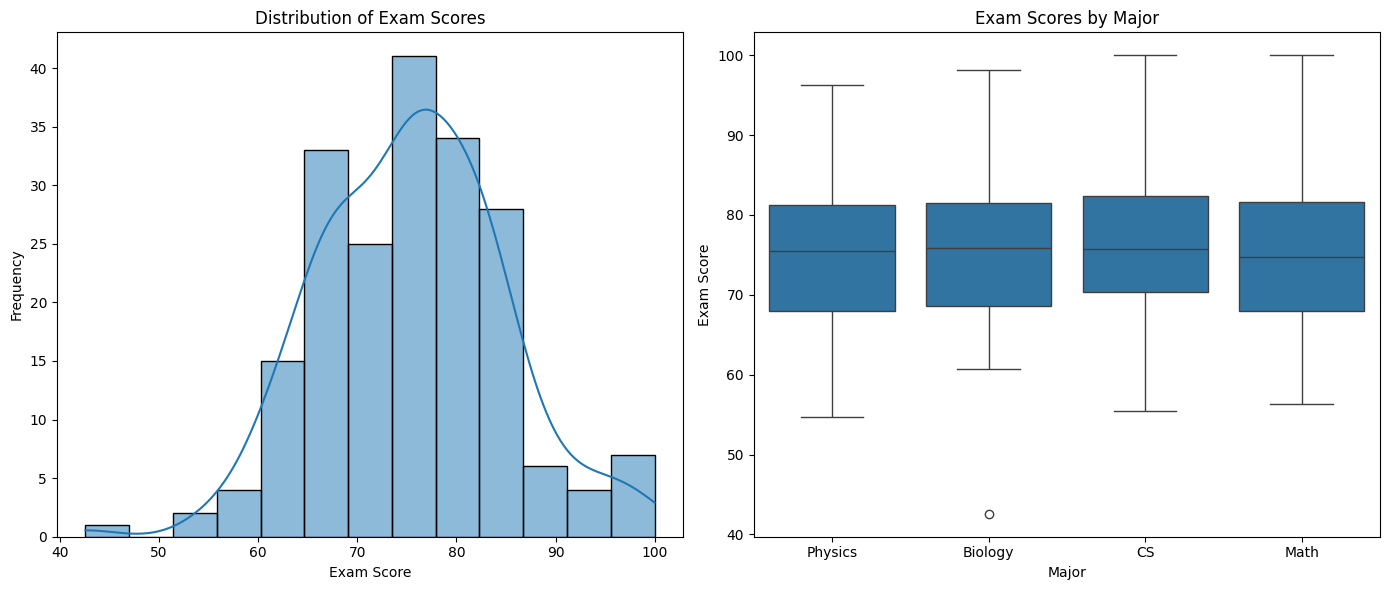

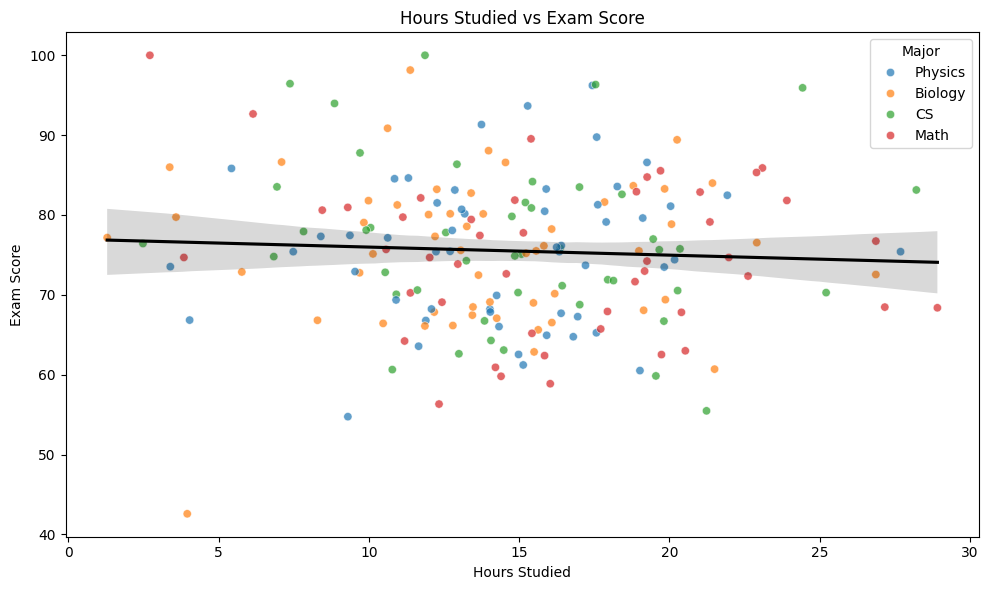

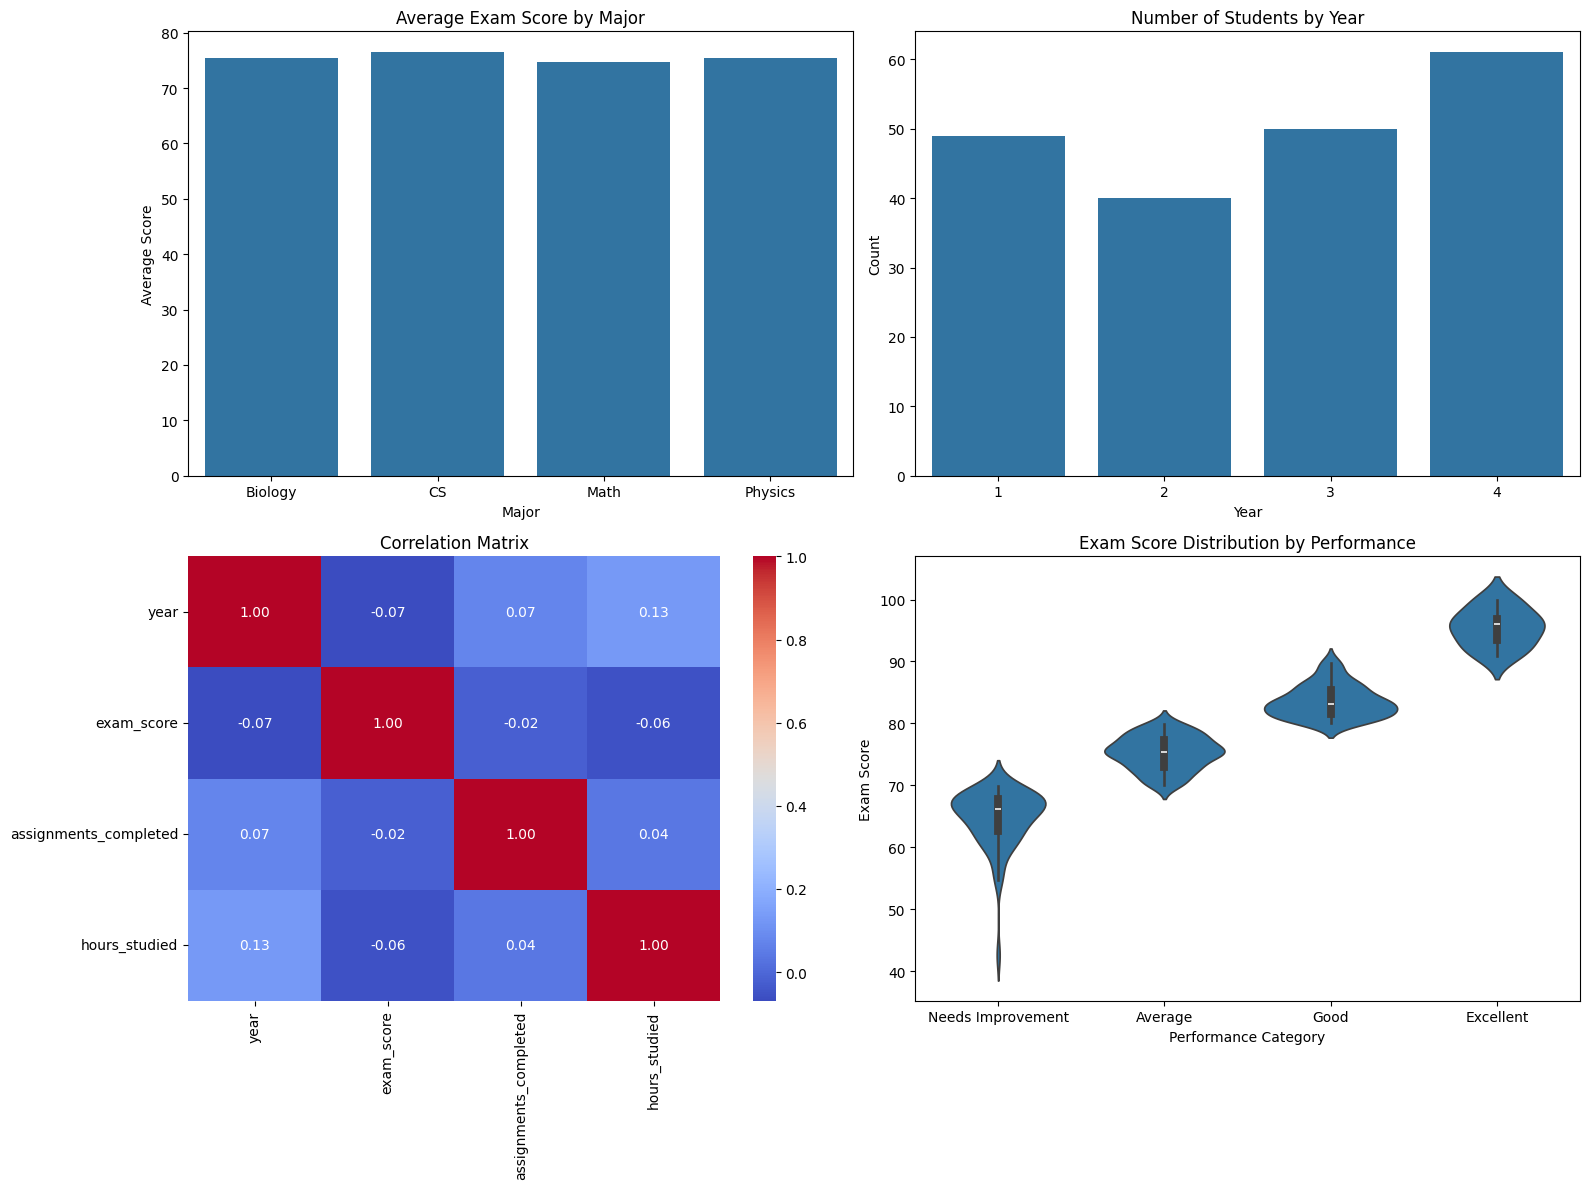

In [6]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Continue using the df from Exercise 5

# Task 1: Distribution Visualization (8 points)
# TODO: Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(
    data=df,
    x='exam_score',
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Distribution of Exam Scores')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Frequency')

sns.boxplot(
    data=df,
    x='major',
    y='exam_score',
    ax=axes[1]
)

# TODO: Add appropriate titles, labels, and styling
axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()



# Task 2: Relationship Visualization (8 points)
# TODO: Create a scatter plot of hours_studied vs exam_score
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major',
    alpha=0.7
)

# TODO: Color points by major
# It is already done using the 'hue' parameter in sns.scatterplot

# TODO: Add a regression line
sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False,
    color='black'
)


# TODO: Include appropriate legends, titles, and axis labels
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend(title='Major')
plt.tight_layout()
plt.show()


# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

avg_scores = df.groupby('major')['exam_score'].mean()

sns.barplot(
    x=avg_scores.index,
    y=avg_scores.values,
    ax=axes[0, 0]
)

axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Score')

sns.countplot(
    data=df,
    x='year',
    ax=axes[0, 1]
)

axes[0, 1].set_title('Number of Students by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')

numeric_columns = [
    'year',
    'exam_score',
    'assignments_completed',
    'hours_studied'
]

corr_matrix = df[numeric_columns].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    ax=axes[1, 0]
)

axes[1, 0].set_title('Correlation Matrix')



# TODO: Adjust layout, add titles, and ensure readability
sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    ax=axes[1, 1]
)

axes[1, 1].set_title('Exam Score Distribution by Performance')
axes[1, 1].set_xlabel('Performance Category')
axes[1, 1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3035/3536919964.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ageGroup_summary = customers.groupby('age_group').agg(


Age Group Summary
           number_of_customers  average_income  average_CLV      total_CLV
age_group                                                                 
18-25                       81    50634.018330   718.371170   58188.064760
26-35                       73    48747.148046   747.738562   54584.915035
36-50                      160    48516.895668   732.796612  117247.457917
51-70                      186    50713.163384   762.693498  141860.990683

Top 10% Customers
    age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6    38  58876.388563                  10          110.331527    0.166667   
9    40  48809.492879                  10          110.228581    0.166667   
19   41  21282.756976                   8          119.651218    0.333333   
24   38  53981.193911                   8          120.320786    0.333333   
57   64  45956.146951                   7          135.470585    0.416667   

            CLV age_group  
6   1287.201143     36

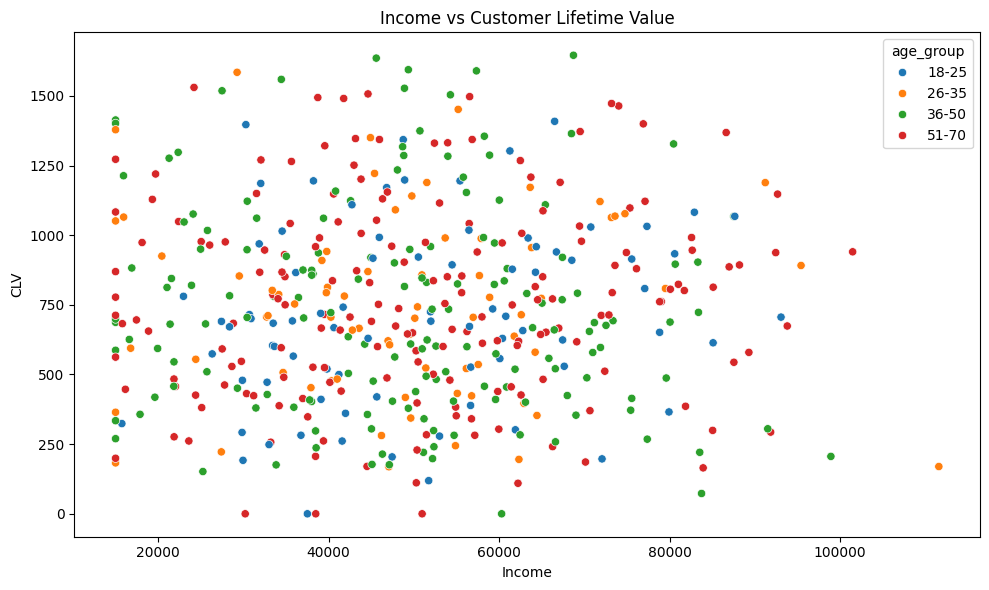

/tmp/ipykernel_3035/3536919964.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_clv = customers.groupby('age_group')['CLV'].mean()


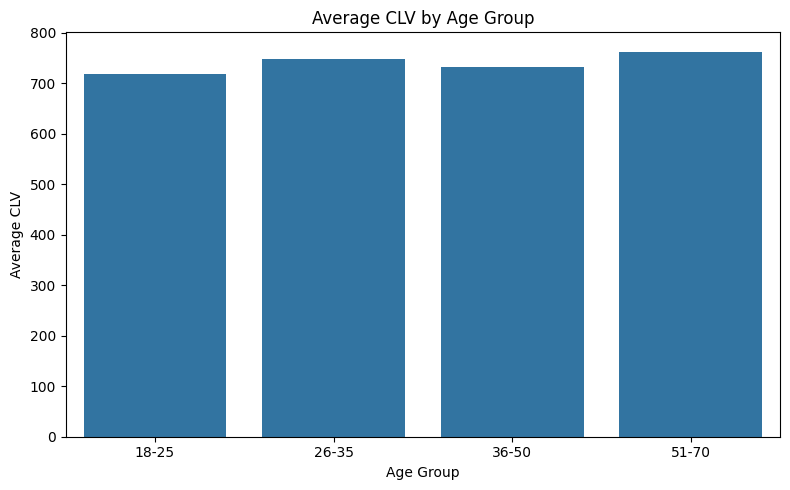

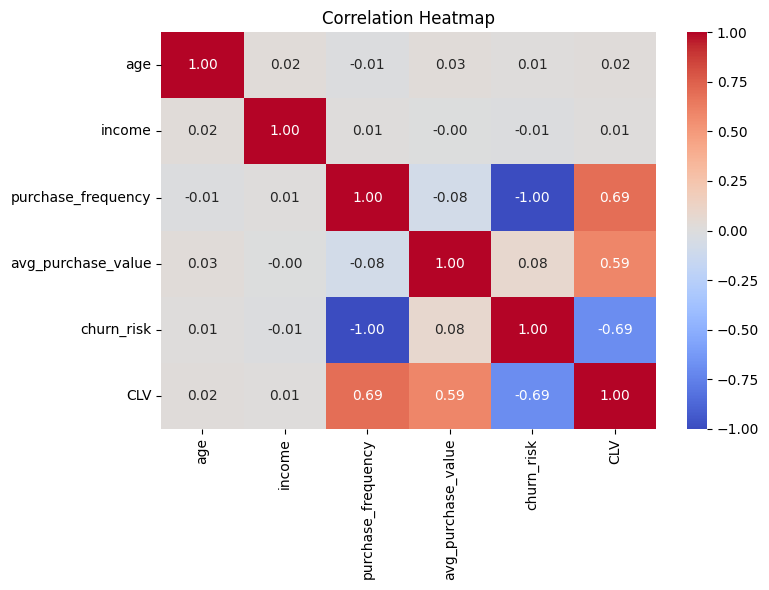

In [8]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)
max_frequency = customers['purchase_frequency'].max()

customers['churn_risk'] = 1 - (
    customers['purchase_frequency'] / max_frequency
)

customers['CLV'] = (
    customers['purchase_frequency']
    * customers['avg_purchase_value']
    * (1 + customers['churn_risk'])
)


# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70
customers['age_group'] = pd.cut(
    customers['age'],
    bins=[18, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '51-70'],
    include_lowest=True
)


# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV
ageGroup_summary = customers.groupby('age_group').agg(
    number_of_customers=('age', 'count'),
    average_income=('income', 'mean'),
    average_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
)

print("Age Group Summary")
print(ageGroup_summary)


# TODO: Identify top 10% of customers by CLV
threshold = customers['CLV'].quantile(0.90)

top_customers = customers[
    customers['CLV'] >= threshold
]

print("\nTop 10% Customers")
print(top_customers.head())

print(f"\nNumber of Top Customers: {len(top_customers)}")


# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
#       2. Bar chart of average CLV by age group
#       3. Correlation heatmap
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group'
)

plt.title('Income vs Customer Lifetime Value')
plt.xlabel('Income')
plt.ylabel('CLV')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

avg_clv = customers.groupby('age_group')['CLV'].mean()

sns.barplot(
    x=avg_clv.index,
    y=avg_clv.values
)

plt.title('Average CLV by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average CLV')
plt.tight_layout()
plt.show()


numeric_cols = [
    'age',
    'income',
    'purchase_frequency',
    'avg_purchase_value',
    'churn_risk',
    'CLV'
]

corr_matrix = customers[numeric_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations

# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations

The 51-70 age group has the highest average CLV which is 762.7 and the difference between the different age groups is very small. Also in the correlation heatmap, purchase frequency and average purchase value are the strong driving force while income has little to no correlation. 
I recommend getting customers to shop more often and spend more money per visit rather than focusing on one age group.